# Example 2.7: $G = \mathrm{Cay}(\mathbb{Z}_{12}, \{2,3\})$

Companion notebook to Example 2.7 of the paper. We solve the unsymmetrized feasibility SDP (12) to numerically certify that $G = \mathrm{Cay}(\mathbb{Z}_{12}, \{2,3\})$ is lower conformally rigid.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np

from cr.solvers import (
    find_edge_isometric_embedding,
    find_orbit_isometric_embedding,
    verify_compressed_edge_isometry,
    verify_edge_isometry,
    verify_orbit_isometry,
)
from cr.orbits import get_edge_orbits

## Graph construction

The circulant $G = \mathrm{Cay}(\mathbb{Z}_{12}, \{2, 3\})$ (HoG 33319) has $n = 12$ vertices and $m = 24$ edges.

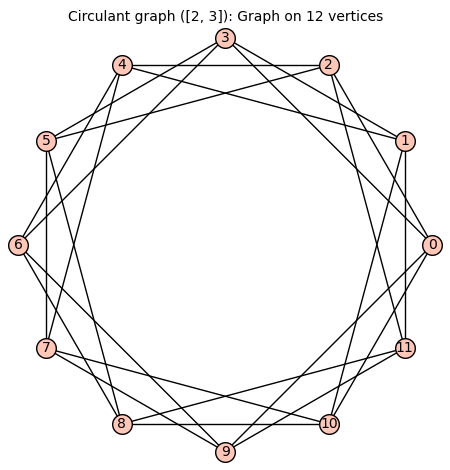

In [2]:
G = graphs.CirculantGraph(12, [2,3])
G

## Eigenspace computation

We form the Laplacian $L$ and compute its spectrum via `numpy.linalg.eigh`. For $G$ we have $\lambda_2 = 3$ with multiplicity 6; the SDP (12) is set up on this eigenspace. `B` is an orthonormal basis of $\mathcal{E}_{\lambda_2}$ obtained from the columns of the eigenvector matrix.

In [3]:
L = G.laplacian_matrix().numpy()
eigvals, eigvecs = np.linalg.eigh(L)

In [4]:
print(L)
print(eigvals)

[[ 4  0 -1 -1  0  0  0  0  0 -1 -1  0]
 [ 0  4  0 -1 -1  0  0  0  0  0 -1 -1]
 [-1  0  4  0 -1 -1  0  0  0  0  0 -1]
 [-1 -1  0  4  0 -1 -1  0  0  0  0  0]
 [ 0 -1 -1  0  4  0 -1 -1  0  0  0  0]
 [ 0  0 -1 -1  0  4  0 -1 -1  0  0  0]
 [ 0  0  0 -1 -1  0  4  0 -1 -1  0  0]
 [ 0  0  0  0 -1 -1  0  4  0 -1 -1  0]
 [ 0  0  0  0  0 -1 -1  0  4  0 -1 -1]
 [-1  0  0  0  0  0 -1 -1  0  4  0 -1]
 [-1 -1  0  0  0  0  0 -1 -1  0  4  0]
 [ 0 -1 -1  0  0  0  0  0 -1 -1  0  4]]
[7.43213303e-16 3.00000000e+00 3.00000000e+00 3.00000000e+00
 3.00000000e+00 3.00000000e+00 3.00000000e+00 4.00000000e+00
 6.00000000e+00 6.00000000e+00 7.00000000e+00 7.00000000e+00]


In [5]:
lam2, B = eigvals[1], eigvecs[:, 1:7]
print(f"lambda_2 = {lam2}, multiplicity = {B.shape[1]}")

lambda_2 = 2.9999999999999996, multiplicity = 6


As a sanity check, $B^\top B = I_6$ confirms that the extracted basis is orthonormal; the solution $Z$ of (12) is parametrized against this specific $B$.

In [6]:
np.allclose(B.T @ B, np.eye(6))

True

## Unsymmetrized SDP

We solve the feasibility SDP of equation (12),

$$ \text{find } Z \succeq 0 \quad\text{s.t.}\quad \langle \tilde{L}^{uv}, Z \rangle_F = 1 \ \text{ for all } uv \in E, $$

where $\tilde{L}^{uv} = B^\top L^{uv} B$. The problem has one constraint per edge, so $|E| = 24$ constraints in a $6 \times 6$ matrix variable. Any solution $Z$ lifts to a solution $\Phi = B Z B^\top$ of the full SDP (11).

For each edge $uv \in E$ the rank-1 matrix $L^{uv} = (e_u - e_v)(e_u - e_v)^\top \in \mathcal{S}^{12}$ has exactly four nonzero entries. Its compression onto the eigenspace is $\tilde{L}^{uv} = B^\top L^{uv} B = (B_u - B_v)(B_u - B_v)^\top \in \mathcal{S}^6$ where $B_u$ is the $u^{\textrm{th}}$ row of $B$. The SDP constraint $\langle \tilde{L}^{uv}, Z \rangle_F = 1$ is equivalent to $(B_u - B_v)^\top Z\,(B_u - B_v) = 1$. We inspect a few examples before solving.

In [7]:
edges = list(G.edges(labels=False))
n = B.shape[0]

for u, v in [(0, 2), (4, 7)]:   # one edge from each orbit
    e = np.zeros(n)
    e[u], e[v] = 1.0, -1.0

    L_uv       = np.outer(e, e)
    L_tilde_uv = np.outer(B[u] - B[v], B[u] - B[v])

    print(f"Edge ({u}, {v})")
    print(f"L^uv  (12×12):")
    print(L_uv)
    print(f"L̃^uv = B^⊤ L^uv B  (6×6):")
    print(L_tilde_uv)
    print()

Edge (0, 2)
L^uv  (12×12):
[[ 1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1. -0.  1. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
L̃^uv = B^⊤ L^uv B  (6×6):
[[ 0.33633952 -0.11652622  0.17302207  0.33968612  0.08719159 -0.02558573]
 [-0.11652622  0.04037099 -0.05994421 -0.11768566 -0.03020789  0.00886428]
 [ 0.17302207 -0.05994421  0.0890072   0.17474365  0.04485369 -0.01316198]
 [ 0.33968612 -0.11768566  0.17474365  0.34306602  0.08805915 -0.0258403 ]
 [ 0.08719159 -0.03020789  0.0448

We can solve the SDP (12) with `find_edge_isometric_embedding(B, edges, tol=1e-8)`, which solves the feasibility SDP and returns a triple `(status, Z, residuals)`.

**Inputs**
- `B` — orthonormal basis for $\mathcal{E}_{\lambda_2}$, shape $(n \times d)$. Used to form the compressed constraints $\tilde{L}^{uv} = (B_u - B_v)(B_u - B_v)^\top$.
- `edges` — list of $(u, v)$ pairs. One constraint $\langle \tilde{L}^{uv}, Z \rangle_F = 1$ is added per edge.
- `tol` — solver tolerance passed to MOSEK (default $10^{-8}$).

**Outputs**
- `status` — `'optimal'` if a feasible $Z$ was found (evidence of lower conformal rigidity), `'infeasible'` if no solution exists.
- `Z` — the solution matrix $Z \in \mathcal{S}^d_+$, or `None` if infeasible. Lifts to the full certificate $\Phi = BZB^\top \in \mathcal{S}^n_+$.
- `residuals` — array of per-edge values $\langle \tilde{L}^{uv}, Z \rangle_F - 1$, one per edge in the same order as `edges`. A residual of $0$ means that constraint is satisfied exactly; values near machine precision indicate a numerically tight solution.

In [8]:
edges = list(G.edges(labels=False))
status, Z, residuals = find_edge_isometric_embedding(B, edges)

Solver used: MOSEK


In [9]:
print(f"status:    {status}")
print()
print("Z:")
print(Z)
print()
print("residuals  (⟨L̃^uv, Z⟩_F − 1 for each edge):")
print(residuals)

status:    optimal

Z:
[[ 1.34991215  0.13207362 -0.02158469 -0.05228898 -0.17836152  0.00782659]
 [ 0.13207362  1.30658582  0.16217889  0.05578852  0.07633413 -0.08132252]
 [-0.02158469  0.16217889  1.23130164 -0.0256525   0.1238908   0.1391959 ]
 [-0.05228898  0.05578852 -0.0256525   1.48054514 -0.05192971  0.01215303]
 [-0.17836152  0.07633413  0.1238908  -0.05192971  1.20383986 -0.06843892]
 [ 0.00782659 -0.08132252  0.1391959   0.01215303 -0.06843892  1.42781539]]

residuals  (⟨L̃^uv, Z⟩_F − 1 for each edge):
[-9.05608921e-13 -6.94333480e-13 -6.94111435e-13 -9.05830966e-13
 -9.05497899e-13 -6.92779167e-13 -6.94333480e-13 -9.06275055e-13
 -9.05941988e-13 -6.94333480e-13 -6.94555524e-13 -9.05719943e-13
 -6.93001212e-13 -9.05608921e-13 -6.93778368e-13 -9.05719943e-13
 -6.94999613e-13 -9.05941988e-13 -6.93445301e-13 -9.05497899e-13
 -6.94333480e-13 -9.05497899e-13 -6.93001212e-13 -9.05608921e-13]


The solver has returned status `optimal` and a numeric certificate $Z$, which we included in Example 2.7 in $\S 5$ of our paper. Even though MOSEK returned `optimal`, the constraints are not satisfied exactly. At MOSEK's default tolerance ($10^{-8}$), the per-edge residuals $\langle \tilde{L}^{uv}, Z \rangle_F - 1$ are on the order of $10^{-13}$, so this computation alone does not formally prove that $G$ is lower conformally rigid.

We can also independently verify our solution $Z$ with `verify_compressed_edge_isometry(B, Z, edges, tol=1e-5)`, which checks each per-edge SDP constraint from `B` and `Z` without trusting the solver's own residual report.

**Inputs**
- `B`, `Z` — same eigenspace basis and certificate matrix as above.
- `edges` — list of $(u,v)$ pairs; checks $\langle \tilde{L}^{uv}, Z\rangle_F = 1$ for each edge individually.
- `tol` — a constraint is flagged if $|\langle \tilde{L}^{uv}, Z\rangle_F - 1| >$ `tol`.

**Output** — `True` if every per-edge constraint passes, `False` (with a printed failure message) otherwise.

Indeed, our candidate $Z$ passes when `tol=1e-12`:

In [10]:
verify_compressed_edge_isometry(B, Z, edges, tol=1e-12)

True

but fails when `tol=1e-13`.

In [11]:
verify_compressed_edge_isometry(B, Z, edges, tol=1e-13)

Edge (0, 2): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (0, 3): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (0, 9): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (0, 10): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (1, 3): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (1, 4): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (1, 10): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (1, 11): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (2, 4): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (2, 5): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (2, 11): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (3, 5): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (3, 6): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (4, 6): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (4, 7): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (5, 7): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (5, 8): tr(L̄ Z) = 1.00000000, expected 1.0  [FAIL]
Edge (6, 8): tr(L̄ Z) = 1.0

False

Tightening the solver tolerance pulls the residuals down by several orders of magnitude. Passing `tol=1e-18` sets MOSEK's primal, dual, infeasibility, and relative-gap tolerances as tight as it will accept.

In [12]:
status, Z, residuals = find_edge_isometric_embedding(B, edges, tol=1e-18)

MOSEK failed (SolverError): Solver 'MOSEK' failed. Try another solver, or solve with verbose=True for more information.
Solver used: SCS (fallback)


In [13]:
residuals

array([ 8.88178420e-15, -2.55351296e-15,  1.17683641e-14,  3.77475828e-15,
        5.99520433e-15, -1.33226763e-15,  4.44089210e-16, -2.22044605e-16,
        2.22044605e-15, -1.11022302e-15,  4.44089210e-16, -5.55111512e-16,
        1.26565425e-14,  3.77475828e-15,  1.11022302e-15,  1.33226763e-15,
       -2.22044605e-16,  1.33226763e-15, -1.66533454e-15, -6.88338275e-15,
       -2.77555756e-15,  6.66133815e-16,  0.00000000e+00, -1.11022302e-16])

The residuals are now $\lesssim 2 \times 10^{-15}$, near machine precision. Even if we could drive them to zero, the certificate would still depend on the numerical basis $B$, which motivates the exact symbolic approach developed later.

We can also lift the certificate to $\Phi = BZB^\top \in \mathcal{S}^{12}_+$ and re-verify the edge constraints directly in $\mathbb{R}^{12}$. Recall that the SDP (11) requries $L \Phi = \lambda \Phi$ and $\langle L^{uv}, \Phi \rangle = 1$ for all $uv \in E$.

In [14]:
Phi = B @ Z @ B.T

# Check L Phi = lambda_2 Phi
print(f"max |L Phi - lambda_2 Phi|: {np.max(np.abs(L @ Phi - lam2 * Phi)):.2e}")

# Check edge constraints Phi[u,u] + Phi[v,v] - 2*Phi[u,v] = 1
edge_vals = np.array([Phi[u, u] + Phi[v, v] - 2 * Phi[u, v] for u, v in edges])
print(f"Edge constraint values (should all be 1):")
print(edge_vals)
print(f"max |constraint - 1|: {np.max(np.abs(edge_vals - 1)):.2e}")

max |L Phi - lambda_2 Phi|: 8.88e-16
Edge constraint values (should all be 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
max |constraint - 1|: 1.24e-14


We see that $L \Phi = \lambda \Phi$ up to a tolerance of `9.44e1-16`, and our edge constraints have the residuals we saw above. We've implemented `verify_edge_isometry`, which wraps the edge check with per-edge failure reporting:

In [15]:
verify_edge_isometry(Phi, edges, tol=2e-15)

Edge (0, 2): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (0, 3): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (0, 9): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (0, 10): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (1, 3): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (2, 4): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (3, 6): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (4, 6): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (7, 9): sq dist = 1.00000000, expected 1.0  [FAIL]
Edge (7, 10): sq dist = 1.00000000, expected 1.0  [FAIL]


False

## Visualizing the edge-isometric embedding

The certificate matrix $\Phi \in \mathcal{S}^{12}_+$ encodes an edge-isometric spectral embedding $\mathcal{P}$ of $G$ on $\mathcal{E}_{\lambda_2}$. The embedding $\mathcal{P}$ corresponds to the matrix $P$ given by the factorization $\Phi = PP^T$. The vertex $i$ gets sent to the point $p_i$ given by the $i^{\textrm{th}}$ row of $P$. 

In [16]:
U, s, _ = np.linalg.svd(Phi)
pos = s > 1e-10
P = U[:, pos] * np.sqrt(s[pos])   # Phi = P @ P.T
print(f"Embedding shape: {P.shape}")
with np.printoptions(precision=4, suppress=True):
    print(P)

Embedding shape: (12, 6)
[[-0.2741  0.4182  0.2639 -0.4247 -0.4072 -0.0294]
 [ 0.0283 -0.4992  0.4409 -0.2358  0.1782  0.3673]
 [ 0.2251  0.4465  0.4997  0.0162  0.229  -0.338 ]
 [-0.4182 -0.2741  0.4247  0.2639 -0.4072 -0.0294]
 [ 0.4992  0.0283  0.2358  0.4409  0.1782  0.3673]
 [-0.4465  0.2251 -0.0162  0.4997  0.229  -0.338 ]
 [ 0.2741 -0.4182 -0.2639  0.4247 -0.4072 -0.0294]
 [-0.0283  0.4992 -0.4409  0.2358  0.1782  0.3673]
 [-0.2251 -0.4465 -0.4997 -0.0162  0.229  -0.338 ]
 [ 0.4182  0.2741 -0.4247 -0.2639 -0.4072 -0.0294]
 [-0.4992 -0.0283 -0.2358 -0.4409  0.1782  0.3673]
 [ 0.4465 -0.2251  0.0162 -0.4997  0.229  -0.338 ]]


This gives us an embedding in $\mathbb{R}^6$. We can use the first two singular vectors of $\Phi$ to get the best approximation in $\mathbb{R}^2$. This recovers the default plot of the graph $G$.

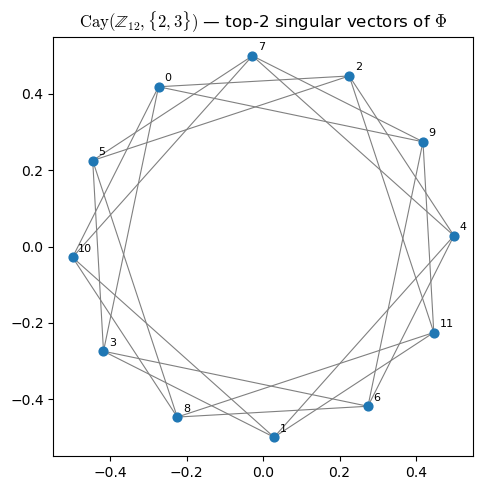

In [17]:
import matplotlib.pyplot as plt

xy = U[:, :2] * np.sqrt(s[:2])

fig, ax = plt.subplots(figsize=(5, 5))
for u, v in edges:
    ax.plot([xy[u, 0], xy[v, 0]], [xy[u, 1], xy[v, 1]], color='gray', lw=0.8, zorder=1)
ax.scatter(xy[:, 0], xy[:, 1], zorder=2, s=40)
for i in range(len(xy)):
    ax.annotate(str(i), xy[i], textcoords='offset points', xytext=(4, 4), fontsize=8)
ax.set_aspect('equal')
ax.set_title(r"$\mathrm{Cay}(\mathbb{Z}_{12},\{2,3\})$ — top-2 singular vectors of $\Phi$")
plt.tight_layout()
plt.show()

`plot_cert_embedding` computes the same embedding and projects to 2D or 3D in one call:

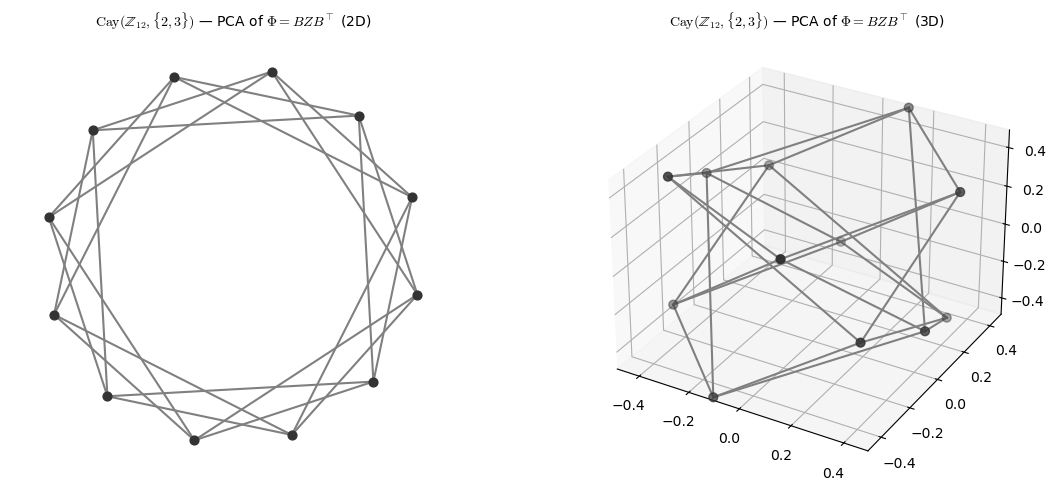

In [18]:
from cr.viz import plot_cert_embedding
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

title = r'$\mathrm{Cay}(\mathbb{Z}_{12},\{2,3\})$ — PCA of $\Phi = BZB^\top$'
plot_cert_embedding(G, B, Z, dim=2, ax=ax2d, title=title + ' (2D)')
plot_cert_embedding(G, B, Z, dim=3, ax=ax3d, title=title + ' (3D)')
plt.tight_layout()
plt.show()

## Symmetry-reduced SDP

We now solve the symmetry-reduced feasibility SDP,

$$ \text{find } Z \succeq 0 \quad\text{s.t.}\quad \langle \tilde{L}^i, Z \rangle_F = |\mathcal{O}_i| \ \text{ for all } 1 \leq i \leq s, $$

where $\tilde{L}^i = \sum_{uv \in \mathcal{O}_i} B^\top L^{uv} B$ and $\mathcal{O}_1, \ldots, \mathcal{O}_s$ partition $E$ into orbits under $\Psi \subseteq \mathrm{Aut}(G)$. We take $\Psi = \mathbb{Z}_{12}$ acting by cyclic shifts $i \mapsto i + 1 \pmod{12}$, which is the Cayley action of $\mathbb{Z}_{12}$ on itself. This collapses the $|E| = 24$ edge constraints to $s = 2$ orbit constraints corresponding to the two generators.

In [19]:
psi = PermutationGroup([[(0,1,2,3,4,5,6,7,8,9,10,11)]], domain=list(range(12)))
edge_orbits = get_edge_orbits(G, psi.gens())

print(f"|Psi| = {psi.order()}")
print(f"number of orbits = {len(edge_orbits)}")
for i, orbit  in enumerate(edge_orbits):
    print(f"orbit {i}: {orbit}")

|Psi| = 12
number of orbits = 2
orbit 0: [(4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (0, 10), (1, 11), (0, 2), (1, 3), (2, 4), (3, 5)]
orbit 1: [(2, 5), (3, 6), (4, 7), (5, 8), (6, 9), (7, 10), (8, 11), (0, 9), (1, 10), (2, 11), (0, 3), (1, 4)]


Solving the symmetry-reduced SDP: 2 constraints on a $6 \times 6$ matrix variable.

In [20]:
status, Z_sym, residuals_sym = find_orbit_isometric_embedding(B, edge_orbits)

Solver used: MOSEK


As before, the solver returned `optimal` with a numerical certificate $Z_\mathrm{sym}$. The residuals $\langle \tilde{L}^i, Z \rangle_F - |\mathcal{O}_i|$ for the two orbits are on the order of `1e-11`.

In [21]:
print(f"status:    {status}")
print()
print("Z_sym:")
print(Z_sym,)
print()
print("residuals  (⟨L̃^i, Z⟩_F − 1 for each edge):")
print(residuals_sym)

status:    optimal

Z_sym:
[[ 1.34991214  0.13207362 -0.02158468 -0.05228897 -0.17836152  0.00782659]
 [ 0.13207362  1.30658582  0.16217889  0.05578852  0.07633413 -0.08132252]
 [-0.02158468  0.16217889  1.23130164 -0.0256525   0.1238908   0.1391959 ]
 [-0.05228897  0.05578852 -0.0256525   1.48054513 -0.05192971  0.01215303]
 [-0.17836152  0.07633413  0.1238908  -0.05192971  1.20383985 -0.06843892]
 [ 0.00782659 -0.08132252  0.1391959   0.01215303 -0.06843892  1.42781539]]

residuals  (⟨L̃^i, Z⟩_F − 1 for each edge):
[-5.09553555e-08 -5.19075467e-08]


`verify_orbit_isometry` re-checks each orbit constraint $\langle \tilde{L}^i, Z \rangle_F = |\mathcal{O}_i|$ directly.

In [22]:
Phi_sym = B @ Z_sym @ B.T
verify_orbit_isometry(Phi_sym, edge_orbits)

True

Interestingly enough, the solution `Z_sym` almost matches our solution `Z` from the unsymmetrized SDP exactly. We are not quite sure why this occurs.

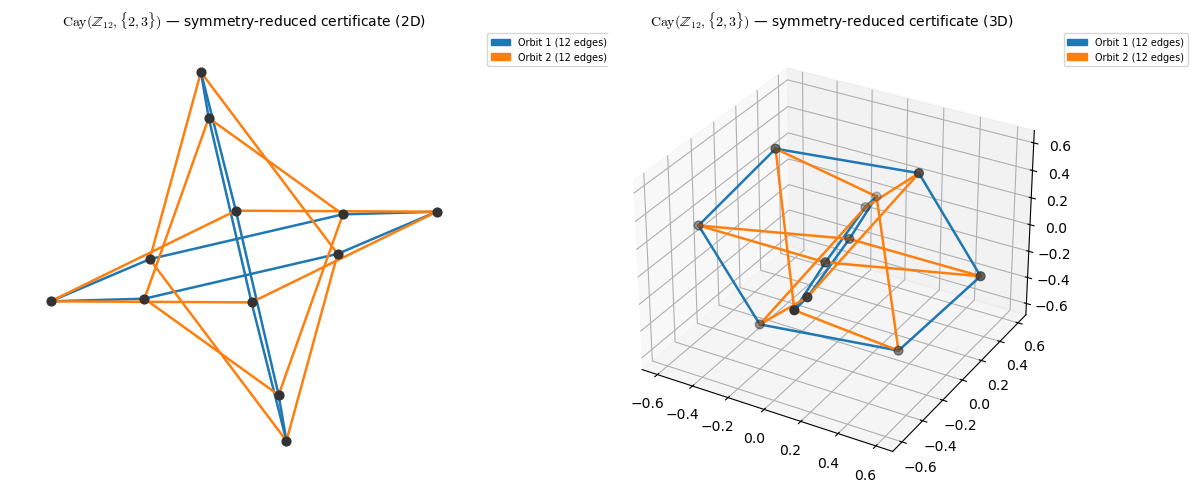

In [23]:
fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

title = r'$\mathrm{Cay}(\mathbb{Z}_{12},\{2,3\})$ — symmetry-reduced certificate'
plot_cert_embedding(G, B, Z_sym, edge_orbits=edge_orbits, dim=2, ax=ax2d, title=title + ' (2D)')
plot_cert_embedding(G, B, Z_sym, edge_orbits=edge_orbits, dim=3, ax=ax3d, title=title + ' (3D)')
plt.tight_layout()
plt.show()

This looks very different from our other plot even though the $\Phi$ is nearly identical! Inspecting the eigenvalues of $\Phi$, we see:

In [24]:
eigvals_Phi = np.linalg.eigvalsh(Phi)
print('Eigenvalues of Phi:')
print(np.sort(eigvals_Phi))

Eigenvalues of Phi:
[-5.65106821e-16 -2.39491020e-16 -8.54839601e-17  1.27302513e-16
  1.90187909e-16  2.77583823e-16  1.00000000e+00  1.00000000e+00
  1.49999985e+00  1.49999985e+00  1.50000015e+00  1.50000015e+00]


$\Phi$ has a maximum eigenvalue of $1.5$ with multiplicity 4. This means when we run PCA in 2 or 3 dimensions, we can choose any set of orthogonal vectors in this 4-dimensional space. We hypothesize that the small numerical differences in $\Phi$ causes the SVD decomposition to identify different sets of orthogonal eigenvectors in this eigenspace, which is why we get such a different projection.

## Exact certification

We now follow §7 of the paper to produce an exact algebraic certificate. Since $G = \mathrm{Cay}(\mathbb{Z}_{12}, \{2,3\})$ is an abelian Cayley graph, Theorem 7.4 guarantees that $\mathcal{E}_{\lambda_2}$ decomposes into real isotypic components each of multiplicity 1 under the action of $\Psi = \mathbb{Z}_{12}$. By Theorem 7.3, the set of achievable orbit-energy distributions $\ell_\Psi(\mathcal{E}_{\lambda_2}) \subseteq \mathbb{R}^s$ is the polyhedral cone generated by the orbit-energy vectors $\ell_\Psi(\varphi_j)$ of one representative eigenvector from each isotypic component $X_j$. By Corollary 7.5, $G$ is lower conformally rigid if and only if there exist nonnegative weights $a_j \geq 0$ such that $\sum_j a_j \ell_\Psi(\varphi_j) = \mathcal{O} = (12, 12)$.

This reduces certification to a linear feasibility check, solved exactly over $\mathbb{A}$ (the algebraic reals) via Sage's `Polyhedron`. The pipeline below mirrors `certify_exact_lcr` in `cr/exact_cert.sage`.

In [25]:
load('../cr/exact_cert.sage')

### Exact eigenspace

We call `eigenspace_exact(G, which='lambda2')` from `cr/exact_cert.sage`, which forms the Laplacian over $\overline{\mathbb{Q}}$, sorts its eigenvalues, and returns the right kernel of $L - \lambda_2 I$ as a row basis matrix $B_{\mathrm{exact}}$ (rows = basis vectors, columns = vertices) together with the exact eigenvalue $\lambda$. Since $\lambda_2 = 3 \in \mathbb{Q}$, the kernel is defined over $\mathbb{Q}$, so the returned basis has rational entries despite being computed over $\overline{\mathbb{Q}}$.

In [26]:
lam, B_exact = eigenspace_exact(G, which='lambda2')
print(f"λ_2: {lam}\nExact eigenspace basis: \n{B_exact.T}")

λ_2: 3
Exact eigenspace basis: 
[ 1  0  0  0  0  0]
[ 0  1  0  0  0  0]
[ 0  0  1  0  0  0]
[ 0  0  0  1  0  0]
[ 0  0  0  0  1  0]
[ 0  0  0  0  0  1]
[-1 -1  0  1  0 -1]
[ 1  0 -1 -1  1  1]
[-1  0  0  0 -1  0]
[ 0 -1  0  0  0 -1]
[ 1  1 -1 -1  0  1]
[-1  0  1  0 -1 -1]


We see that we get a basis of 6 vectors. We can verify that these are eigenvectors:

In [27]:
L_exact = G.laplacian_matrix().change_ring(QQbar)
L_exact * B_exact.T - lam * B_exact.T

[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]
[0 0 0 0 0 0]

### Subrepresentation on $\mathcal{E}_{\lambda_2}$

Under the choice of basis `B_exact`, each $g \in \Psi = \mathbb{Z}_{12}$ acts on $\mathcal{E}_{\lambda_2}$ by an exact $6 \times 6$ matrix $M_g$. `build_subrep` solves for $M_g$ on the generators and propagates to all of $\Psi$ by matrix multiplication.

In [28]:
subrep = build_subrep(B_exact, psi)
for g, M in subrep.items():
    print(f"permuation: {g}")
    print(M)

permuation: ()
[1 0 0 0 0 0]
[0 1 0 0 0 0]
[0 0 1 0 0 0]
[0 0 0 1 0 0]
[0 0 0 0 1 0]
[0 0 0 0 0 1]
permuation: (0,1,2,3,4,5,6,7,8,9,10,11)
[-1  1  0  0  0  0]
[ 0  0  1  0  0  0]
[ 1  0  0  1  0  0]
[ 0  0  0  0  1  0]
[-1  0  0  0  0  1]
[-1  0  0  0  0  0]
permuation: (0,2,4,6,8,10)(1,3,5,7,9,11)
[ 1 -1  1  0  0  0]
[ 1  0  0  1  0  0]
[-1  1  0  0  1  0]
[-1  0  0  0  0  1]
[ 0 -1  0  0  0  0]
[ 1 -1  0  0  0  0]
permuation: (0,3,6,9)(1,4,7,10)(2,5,8,11)
[ 0  1 -1  1  0  0]
[-1  1  0  0  1  0]
[ 0 -1  1  0  0  1]
[ 0 -1  0  0  0  0]
[ 0  0 -1  0  0  0]
[-1  1 -1  0  0  0]
permuation: (0,4,8)(1,5,9)(2,6,10)(3,7,11)
[-1  0  1 -1  1  0]
[ 0 -1  1  0  0  1]
[ 0  0 -1  1  0  0]
[ 0  0 -1  0  0  0]
[-1  0  0 -1  0  0]
[ 0 -1  1 -1  0  0]
permuation: (0,5,10,3,8,1,6,11,4,9,2,7)
[ 1 -1  0  1 -1  1]
[ 0  0 -1  1  0  0]
[-1  0  0 -1  1  0]
[-1  0  0 -1  0  0]
[ 1 -1  0  0 -1  0]
[ 1  0 -1  1 -1  0]
permuation: (0,6)(1,7)(2,8)(3,9)(4,10)(5,11)
[-1  1 -1  0  1 -1]
[-1  0  0 -1  1  0]
[ 0 -1  0 

We remark that `B_exact` is not an orthonormal basis, so the representing matrices $M_g$ are not unitary.

### Irreducible decomposition

To apply Theorem 7.3 we need the **real** isotypic decomposition $\mathcal{E}_{\lambda_2} = X_1 \oplus \cdots \oplus X_h$, where each $X_j$ is the isotypic component for a distinct real irreducible representation $U_j$ of $\Psi$. Since each has multiplicity 1, it contributes one extreme ray $\ell_\Psi(\varphi_j)$ to the polyhedral cone. To obtain this decomposition, it will be more convenient to work with $\mathcal{E}_{\lambda_2}$ as a complex representation.

**Why compute over $\mathbb{C}$?** Sage's character table and inner product formula are implemented over $\mathbb{C}$. The standard decomposition uses the Hermitian inner product $m_i = \frac{1}{|\Psi|} \sum_{g} \chi(g)\overline{\chi_i(g)}$ to count how many times each complex irrep $\chi_i$ appears in $\mathcal{E}_{\lambda_2}$.

**Recovering real isotypics via the Frobenius-Schur indicator.** For each active complex irrep $\chi_i$, the indicator $\mathrm{FS}(\chi_i) = \frac{1}{|\Psi|}\sum_{g \in \Psi} \chi_i(g^2)$ takes values in $\{+1, 0, -1\}$ and determines how it fuses into a real irrep:
- **FS = +1** (real type): $\chi_i$ is already defined over $\mathbb{R}$; it forms a 1-dimensional real isotypic component on its own.
- **FS = 0** (complex type): $\chi_i$ is not self-conjugate; it pairs with its conjugate $\overline{\chi_i}$ to form a single 2-dimensional real isotypic component.
- **FS = -1** (quaternionic type): $\chi_i$ is self-conjugate but not realizable over $\mathbb{R}$; two copies fuse into a quaternionic-type real isotypic.

In [29]:
ct = psi.character_table()
classes = psi.conjugacy_classes()

chi = subrep_character(subrep, psi)
decomp = irrep_decomposition(chi, psi, ct, classes)
fs_indicators = frobenius_schur_indicators(psi, ct, classes, decomp)

print("Active irreps (idx, dim, mult, FS):")
for idx, dim, mult in decomp:
    print(f"  idx={idx}, dim={dim}, mult={mult}, FS={fs_indicators[idx]}")

Active irreps (idx, dim, mult, FS):
  idx=2, dim=1, mult=1, FS=0
  idx=4, dim=1, mult=1, FS=0
  idx=8, dim=1, mult=1, FS=0
  idx=9, dim=1, mult=1, FS=0
  idx=10, dim=1, mult=1, FS=0
  idx=11, dim=1, mult=1, FS=0


We see all 6 active complex irreducibles have FS $= 0$ with multiplicity 1, so they form 3 conjugate pairs, yielding 3 distinct, complex type irreducible representations each of dimension 2. Now we need to select one $\varphi_j$ in each real irreducible $U_j$.

### Real isotypic projectors

The orthogonal projector onto the isotypic component of irrep $\chi_i$ is
$$P_i = \frac{d_i}{|\Psi|} \sum_{g \in \Psi} \overline{\chi_i(g)}\, M_g,$$
where $d_i = \chi_i(e)$ is the irrep dimension and $M_g$ are the subrep matrices. Summing by conjugacy class, this becomes
$$P_i = \frac{d_i}{|\Psi|} \sum_k \overline{\chi_i(g_k)}\, S_k,$$
where $S_k = \sum_{g \in C_k} M_g$ is the class sum of subrep matrices.

**Combining conjugate pairs to get a real projector.** For a complex-type pair $\{i, j\}$ with $\chi_{j} = \overline{\chi_i}$ and $d_i = d_{\bar{i}}$, the two individual projectors $P_i$ and $P_{j} = \overline{P_i}$ are complex-valued. Their sum is real:
$$P_i + P_{j} = \frac{d_i}{|\Psi|} \sum_g \bigl[\overline{\chi_i(g)} + \overline{\chi_{j}(g)}\bigr] M_g
= \frac{d_i}{|\Psi|} \sum_g \bigl[\overline{\chi_i(g)} + \chi_i(g)\bigr] M_g
= \frac{2d_i}{|\Psi|} \sum_g \mathrm{Re}(\chi_i(g))\, M_g.$$
Since the $M_g$ are rational matrices, this is real-valued. $P_i + P_j$ is the orthogonal projector onto the 2-dimensional real isotypic component. `isotypic_projectors` builds the exact $6 \times 6$ real projector onto each isotypic component: for FS = 0 pairs it sums the two conjugate projectors; for FS = $\pm 1$ irreps it takes $P_i$ alone.

In [30]:
paired_irreps = pair_complex_conjugates(decomp, ct, fs_indicators)
print(f"conjugate pairs: {paired_irreps}")
projectors = isotypic_projectors(subrep, psi, ct, classes, paired_irreps)

conjugate pairs: [[2, 4], [8, 11], [9, 10]]


For $\Psi = \mathbb{Z}_{12}$, the characters are $\chi_k(j) = \zeta_{12}^{jk}$ where $\zeta_{12}$ is the primitive $12^{\textrm{th}}$ root of unity. The three active conjugate pairs from the Sage character table correspond to $k \in \{1, 4, 5\}$ from Example 2.7:
| Sage pair | Fourier mode $k$ 
|-----------|-----------------
| $\{2,\, 4\}$ | $k = 4$ 
| $\{8,\,11\}$ | $k = 5$ 
| $\{9,\,10\}$ | $k = 1$ 

### Orbit-energy distributions

Now we pick a vector $\varphi_i$ in each $X_i$. We can do this by selecting the first nonzero column of the orthogonal projector $P_i$ to get an appropriate linear combination of basis vectors in `B_exact`. Then we compute the orbit-energy distribution $\ell_\Psi(\varphi_i)$ for each $\varphi_i$ to get the generators of the polyhedral cone in Theorem 7.3.

In [31]:
phi_vectors = get_isotypic_representative(projectors, B_exact)
energies = orbit_energies(phi_vectors, edge_orbits)

print("Orbit sizes:", [len(o) for o in edge_orbits])
for idx, ells in energies.items():
    print(f"  irrep {idx}: {[entry.radical_expression() for entry in ells]}")

Orbit sizes: [12, 12]
  irrep 2: [6, 0]
  irrep 8: [sqrt(3) + 2, 2*sqrt(3) + 4]
  irrep 9: [-sqrt(3) + 2, -2*sqrt(3) + 4]


We already see that `irrep 2` has orbit energy $(6,0)$, and the other two irreducibles have orbit energy proporitional to $(1,2)$. This matches our computation of Example 2.7 in $\S 7$.

### Polyhedral feasibility

We need to find non-negative coefficients $a_i \geq 0$ such that $\sum_i a_i \, \ell_\Psi(\varphi_i) = (|\mathcal{O}_1|, |\mathcal{O}_2|) = (12, 12)$. Even though this particular example is easy enough to solve by hand, `exact_weights` solves this as exact LP feasibility over $\mathbb{A}$ (the algebraic reals) via Sage's `Polyhedron`.

In [32]:
weights = exact_weights(energies, edge_orbits)
print("Weights:", {k: v.radical_expression() for k, v in weights.items()})

Weights: {2: 1, 8: -3*sqrt(3) + 6, 9: 3*sqrt(3) + 6}


### Certificate vector and verification

Combine into $\varphi = \sum_i \sqrt{a_i}\, \varphi_i \in \mathbb{A}^V$. We then manually verify the two conditions from Definition 1.2:
1. **Eigenvector check:** $L\varphi = \lambda_2 \varphi$ (exact, over $\mathbb{A}$).
2. **Orbit-energy check:** $\sum_{(u,v) \in O_i} (\varphi_u - \varphi_v)^2 = |O_i|$ for each edge orbit $O_i$.

In [33]:
phi_exact = combine_certificate(phi_vectors, weights)
print([entry.radical_expression() for entry in phi_exact])

[sqrt(2), 1/2, 1/2*sqrt(2) - 1/2, 0, -1/2*sqrt(2) + 1/2, -1/2, -sqrt(2), 1/2, -1/2*sqrt(2) - 1/2, 0, 1/2*sqrt(2) + 1/2, -1/2]


In [34]:
# Manual eigenvector check: L phi == lam * phi
residual = L_exact * phi_exact - lam * phi_exact
print('Residual entries:', list(residual))
print('Eigenvector check passed:', all(x == 0 for x in residual))

Residual entries: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Eigenvector check passed: True


In [35]:
# Manual orbit-energy check: sum_{(u,v) in O_i} (phi[u]-phi[v])^2 == |O_i|
for i, orbit in enumerate(edge_orbits):
    energy = sum((phi_exact[u] - phi_exact[v])^2 for u, v in orbit)
    print(f'Orbit {i}: energy = {energy.radical_expression()},  '
          f'expected = {len(orbit)},  match = {bool(energy == len(orbit))}')

Orbit 0: energy = 12,  expected = 12,  match = True
Orbit 1: energy = 12,  expected = 12,  match = True


The entire pipeline above — exact eigenspace, subrep, isotypic decomposition, projectors, orbit energies, feasibility LP, and certificate verification — is wrapped in a single call to `certify_exact_lcr`.

In [36]:
certify_exact_lcr(G, aut_group=psi, edge_orbits=edge_orbits)

(1.414213562373095?, 0.500000000000000?, 0.2071067811865476?, 0, -0.2071067811865476?, -0.500000000000000?, -1.414213562373095?, 0.500000000000000?, -1.207106781186548?, 0, 1.207106781186548?, -0.500000000000000?)

We can also visualize the edge-isometric symmetrized embeddings corresponding to this 1-dimensional orbit-isometric embedding.

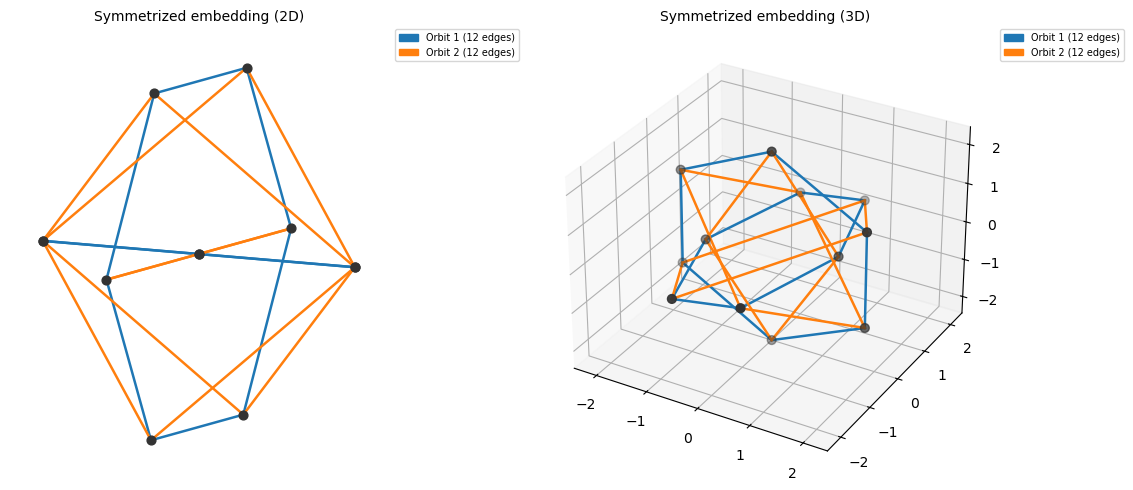

In [37]:
from cr.viz import plot_symmetrized_embedding
import matplotlib.pyplot as plt

phi_np = np.array([float(v) for v in phi_exact])
aut_perms = [[psi_elem(i) for i in range(G.order())] for psi_elem in psi]

fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           dim=2, ax=ax2d, title='Symmetrized embedding (2D)')
plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           dim=3, ax=ax3d, title='Symmetrized embedding (3D)')
plt.tight_layout()
plt.show()